In [285]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from missforest import MissForest
from sklearn.cluster import AgglomerativeClustering as AG
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import json
from pathlib import Path


In [463]:
train_imp = pd.read_csv("/Users/minhu/CS6530/Project/Final/cVAE_imputed_train.csv",header=None).to_numpy()
test_imp = pd.read_csv("/Users/minhu/CS6530/Project/Final/cVAE_imputed_test.csv",header=None).to_numpy()

# Data Generation

In [286]:
def simulate_structured_fair_imputation(
    n=1000,
    d=100,
    p_major=0.8,
    missing_rate_major=0.05,
    missing_rate_minor=0.60,
    cluster_sep=2.0,
    random_state=None,
):
    rng = np.random.default_rng(random_state)

    # 1) True clusters
    clusters = rng.integers(0, 2, size=n)

    # 2) Sensitive attribute independent of cluster
    sensitive = rng.binomial(1, 1 - p_major, size=n)

    # 3) Cluster-specific means
    d = int(d)
    mu0 = np.zeros(d)
    mu1 = np.zeros(d)
    mu1[:10] = cluster_sep

    cov = np.eye(d)
    X_true = np.zeros((n, d))
    X_true[clusters == 0] = rng.multivariate_normal(mu0, cov, size=(clusters == 0).sum())
    X_true[clusters == 1] = rng.multivariate_normal(mu1, cov, size=(clusters == 1).sum())

    # 4) Outcome
    beta = np.linspace(0.5, 2.0, d)
    linear = X_true @ beta + rng.normal(0, 1, n)
    y_reg = linear
    p = 1 / (1 + np.exp(-linear))
    y_class = (p > 0.5).astype(int)

    # 5) Missingness
    missing_mask = np.zeros_like(X_true, dtype=bool)
    eps = 1e-6

    base_rate = np.where(sensitive == 0, missing_rate_major, missing_rate_minor)
    logit_base = np.log((base_rate + eps) / (1 - base_rate + eps))

    feat_idx = range(0,10)
    Z = X_true[:, feat_idx]
    Z_std = np.std(Z, axis=0, keepdims=True)
    Z_std[Z_std < 1e-6] = 1e-6
    Z_scaled = Z / Z_std
    z = Z_scaled.mean(axis=1)  # or use weights

    logit = logit_base + 0.5 * z
    prob = 1 / (1 + np.exp(-logit))
    prob_mat = np.repeat(prob[:, None], d, axis=1)
    missing_mask = rng.random((n, d)) < prob_mat


    X_obs = X_true.copy()
    X_obs[missing_mask] = np.nan

    idx = np.arange(len(X_true))
    train_idx, test_idx = train_test_split(
        idx, test_size=0.3, random_state=0, stratify=clusters
    )

    X_train_true, X_test_true = X_true[train_idx], X_true[test_idx]
    X_train_miss, X_test_miss = X_obs[train_idx], X_obs[test_idx]

    y_reg_train, y_reg_test = y_reg[train_idx], y_reg[test_idx]
    y_class_train, y_class_test = y_class[train_idx], y_class[test_idx]
    clusters_train, clusters_test = clusters[train_idx], clusters[test_idx]
    sensitive_train, sensitive_test = sensitive[train_idx], sensitive[test_idx]

    train_maj = sensitive_train == 0
    train_min = sensitive_train == 1
    test_maj  = sensitive_test == 0
    test_min  = sensitive_test == 1

    missing_mask_train = missing_mask[train_idx]
    missing_mask_test  = missing_mask[test_idx]

    return (X_train_true, X_test_true, y_reg_train, y_reg_test,y_class_train, y_class_test, 
            X_train_miss, X_test_miss,
            train_maj, train_min, test_maj, test_min,
            clusters_train, clusters_test, sensitive_train, sensitive_test,missing_mask_train, missing_mask_test)

In [287]:
(X_train_true, X_test_true, y_reg_train, y_reg_test,y_class_train, y_class_test, 
            X_train_miss, X_test_miss,
            train_maj, train_min, test_maj, test_min,
            clusters_train, clusters_test, sensitive_train, sensitive_test,missing_mask_train, missing_mask_test) = simulate_structured_fair_imputation()

In [292]:
pd.DataFrame(X_train_true).to_csv("/Users/minhu/CS6530/Project/Final/X_train_true.csv",header=False, index=False)
pd.DataFrame(missing_mask_train).to_csv("/Users/minhu/CS6530/Project/Final/missing_mask_train.csv",header=False, index=False)
pd.DataFrame(X_test_true).to_csv("/Users/minhu/CS6530/Project/Final/X_test_true.csv",header=False, index=False)
pd.DataFrame(missing_mask_test).to_csv("/Users/minhu/CS6530/Project/Final/missing_mask_test.csv",header=False, index=False)

pd.DataFrame(sensitive_train).to_csv("/Users/minhu/CS6530/Project/Final/sensitive_train.csv",header=False, index=False)
pd.DataFrame(sensitive_test).to_csv("/Users/minhu/CS6530/Project/Final/sensitive_test.csv",header=False, index=False)

In [414]:
def impute(train_data = X_train_miss, test_data = X_test_miss, method="Mean"):
    if method == "Mean":
        imp = SimpleImputer(missing_values=np.nan, strategy='mean')
    elif method == "Median":
        imp = SimpleImputer(missing_values=np.nan, strategy="median")
    elif method =="MissForest":
        imp = MissForest()
        train_data = pd.DataFrame(train_data)
        test_data = pd.DataFrame(test_data)
    
    imp.fit(train_data)
    train_imp = imp.transform(train_data)
    test_imp = imp.transform(test_data)

    if method =="MissForest":
        train_imp = train_imp.to_numpy()
        test_imp = test_imp.to_numpy()
        
    return train_imp, test_imp

In [450]:
train_imp, test_imp = impute(method="MissForest")

/Users/minhu/anaconda3/envs/squidpy/lib/python3.10/site-packages/missforest/missforest.py:333: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
100%|██████████| 5/5 [04:25<00:00, 53.07s/it]
/Users/minhu/anaconda3/envs/squidpy/lib/python3.10/site-packages/missforest/missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
/Users/minhu/anaconda3/envs/squidpy/lib/python3.10/site-packages/missforest/missforest.py:494: UserWarning: In version 4.2.3, estimator fitting process is moved to `fit` method. `MissForest` will now imputes unseen missing values with fitted estimators with `transform` method. To retain the old behaviour, use `fit_transform` to fit the whole unseen data 

# Imputation Performance

## MSIE

### Overall

In [464]:
diff_train = train_imp[missing_mask_train] - X_train_true[missing_mask_train]
mse_impute_train = np.mean(diff_train**2)

diff_test = test_imp[missing_mask_test] - X_test_true[missing_mask_test]
mse_impute_test = np.mean(diff_test**2)

print("Train MSIE:", mse_impute_train)
print("Test MSIE:", mse_impute_test)


Train MSIE: 1.0611979940645706
Test MSIE: 1.064652993721682


In [419]:
def group_imputation_mse(X_true, X_imp, missing_mask, sensitive, group_val):
    group_idx = (sensitive == group_val)
    mask_group = missing_mask[group_idx]
    true_group = X_true[group_idx]
    imp_group  = X_imp[group_idx]
    diff = imp_group[mask_group] - true_group[mask_group]
    return np.mean(diff**2)

In [465]:
msie_major_train = group_imputation_mse(X_train_true, train_imp, missing_mask_train, 
                                 sensitive_train, group_val=0)
msie_minor_train = group_imputation_mse(X_train_true, train_imp, missing_mask_train, 
                                 sensitive_train, group_val=1)

print("Train Majority MSE:", msie_major_train)
print("Train Minority MSE:", msie_minor_train)


msie_major_test = group_imputation_mse(X_test_true, test_imp, missing_mask_test, 
                                 sensitive_test, group_val=0)
msie_minor_test = group_imputation_mse(X_test_true, test_imp, missing_mask_test, 
                                 sensitive_test, group_val=1)

print("Test Majority MSE:", msie_major_test)
print("Test Minority MSE:", msie_minor_test)

Train Majority MSE: 1.0046060488658006
Train Minority MSE: 1.0827992196100056
Test Majority MSE: 1.0476325089024174
Test Minority MSE: 1.0718930809323521


## IFR

In [466]:
ifr_train = np.abs(msie_major_train - msie_minor_train)
print(ifr_train)

ifr_test = np.abs(msie_major_test - msie_minor_test)
print(ifr_test)

0.07819317074420495
0.0242605720299347


## FIS

In [467]:
fis_train = np.abs(msie_major_train - msie_minor_train) + msie_major_train + msie_minor_train
print(fis_train)

fis_test = np.abs(msie_major_test - msie_minor_test) + msie_major_test + msie_minor_test
print(fis_test)

2.165598439220011
2.1437861618647043


# Clustering

In [483]:
train_imp, test_imp = impute(method="MissForest")
AG_imp  = AG(n_clusters=2).fit(train_imp)
labels_imp_missforest  = AG_imp.labels_

train_imp, test_imp = impute(method="Mean")
AG_imp  = AG(n_clusters=2).fit(train_imp)
labels_imp_mean  = AG_imp.labels_

train_imp, test_imp = impute(method="Median")
AG_imp  = AG(n_clusters=2).fit(train_imp)
labels_imp_median  = AG_imp.labels_

train_imp = pd.read_csv("/Users/minhu/CS6530/Project/Final/cVAE_imputed_train.csv",header=None).to_numpy()
AG_imp  = AG(n_clusters=2).fit(train_imp)
labels_imp_cvae  = AG_imp.labels_

/Users/minhu/anaconda3/envs/squidpy/lib/python3.10/site-packages/missforest/missforest.py:333: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
100%|██████████| 5/5 [04:25<00:00, 53.05s/it]
/Users/minhu/anaconda3/envs/squidpy/lib/python3.10/site-packages/missforest/missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
/Users/minhu/anaconda3/envs/squidpy/lib/python3.10/site-packages/missforest/missforest.py:494: UserWarning: In version 4.2.3, estimator fitting process is moved to `fit` method. `MissForest` will now imputes unseen missing values with fitted estimators with `transform` method. To retain the old behaviour, use `fit_transform` to fit the whole unseen data 

In [485]:
AG_true = AG(n_clusters=2).fit(X_train_true)
AG_imp  = AG(n_clusters=2).fit(train_imp)

clusters_labels = clusters_train
labels_true = AG_true.labels_
labels_imp  = AG_imp.labels_

# ---- 2. Label-based discrepancy ----
ari_true = adjusted_rand_score(clusters_labels, labels_true)
ari_true_major = adjusted_rand_score(clusters_labels[train_maj], labels_true[train_maj])
ari_true_minor = adjusted_rand_score(clusters_labels[train_min], labels_true[train_min])

ari_imp = adjusted_rand_score(clusters_labels, labels_imp)
ari_imp_major = adjusted_rand_score(clusters_labels[train_maj], labels_imp[train_maj])
ari_imp_minor = adjusted_rand_score(clusters_labels[train_min], labels_imp[train_min])

nmi_true = normalized_mutual_info_score(clusters_labels, labels_true)
nmi_true_major = normalized_mutual_info_score(clusters_labels[train_maj], labels_true[train_maj])
nmi_true_minor = normalized_mutual_info_score(clusters_labels[train_min], labels_true[train_min])

nmi_imp = normalized_mutual_info_score(clusters_labels, labels_imp)
nmi_imp_major = normalized_mutual_info_score(clusters_labels[train_maj], labels_imp[train_maj])
nmi_imp_minor = normalized_mutual_info_score(clusters_labels[train_min], labels_imp[train_min])

print("ARI true:", ari_true)
print("ARI true major:", ari_true_major)
print("ARI true minor:", ari_true_minor)

print("\n ARI imputed:", ari_imp)
print("ARI imputed major:", ari_imp_major)
print("ARI imputed minor:", ari_imp_minor)

print("\n NMI true:", nmi_true)
print("NMI true major:", nmi_true_major)
print("NMI true minor:", nmi_true_minor)

print("\n NMI imputed:", nmi_imp)
print("NMI imputed major:", nmi_imp_major)
print("NMI imputed minor:", nmi_imp_minor)

ARI true: 0.9715919950594223
ARI true major: 0.9634393989317678
ARI true minor: 1.0

 ARI imputed: 0.8727066192159432
ARI imputed major: 0.9634394138842292
ARI imputed minor: 0.5914270914892585

 NMI true: 0.9406638297378349
NMI true major: 0.9269180034663128
NMI true minor: 1.0

 NMI imputed: 0.804799756944311
NMI imputed major: 0.9246753497494584
NMI imputed minor: 0.5797349837897965


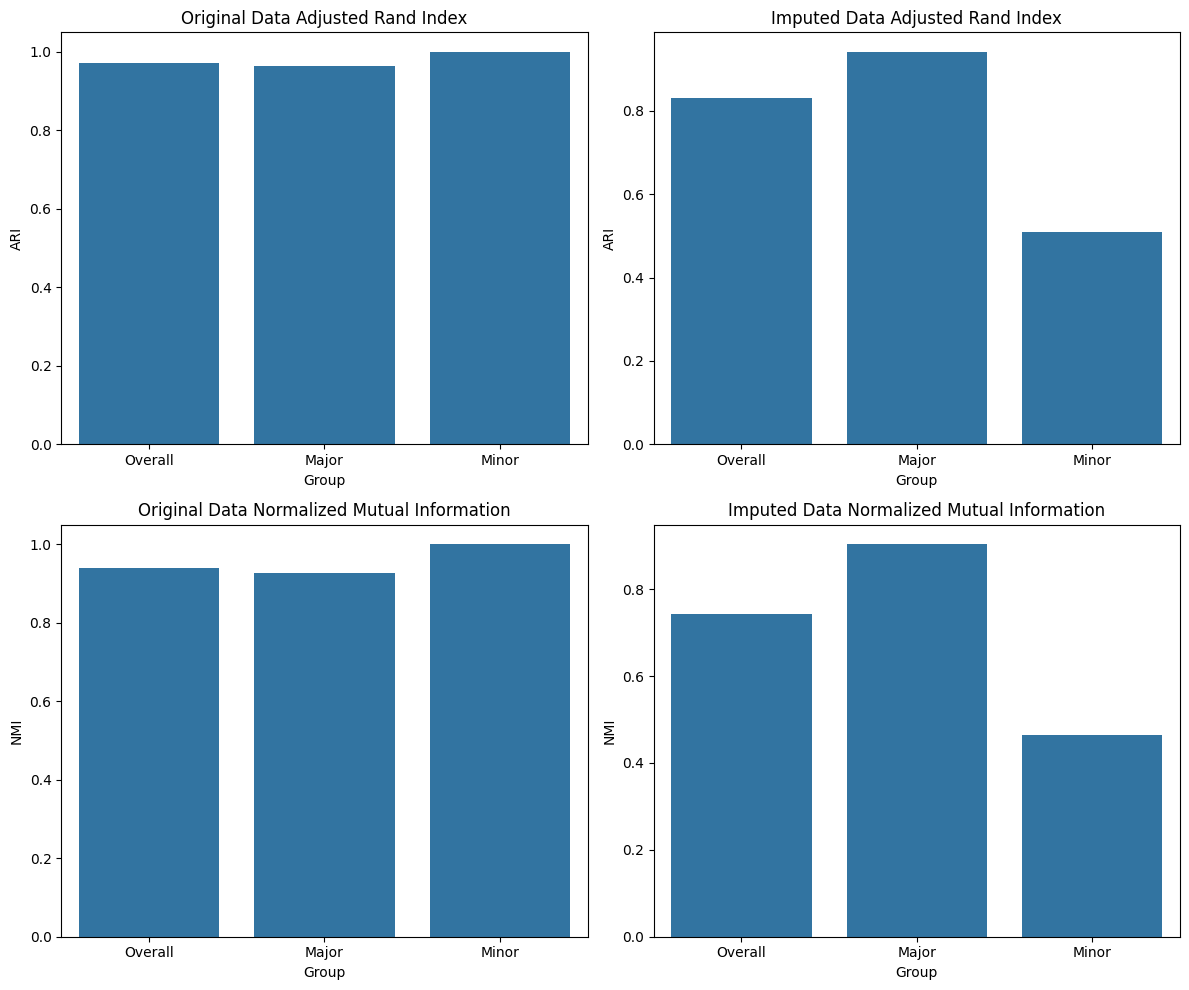

In [254]:
original_ARI_df = pd.DataFrame({"Overall": [ari_true],
                   "Major": [ari_true_major],
                   "Minor": [ari_true_minor]})

original_NMI_df = pd.DataFrame({"Overall": [nmi_true], 
                   "Major": [nmi_true_major], 
                   "Minor": [nmi_true_minor]})

imputed_ARI_df = pd.DataFrame({
                   "Overall": [ari_imp], 
                   "Major": [ari_imp_major], 
                   "Minor": [ari_imp_minor]})

imputed_NMI_df = pd.DataFrame({
                   "Overall": [nmi_imp], 
                   "Major": [nmi_imp_major], 
                   "Minor": [nmi_imp_minor]
                   })

original_ARI_df_long = original_ARI_df.melt(var_name="Group", value_name="ARI")
original_NMI_df_long = original_NMI_df.melt(var_name="Group", value_name="NMI")
imputed_ARI_df_long = imputed_ARI_df.melt(var_name="Group", value_name="ARI")
imputed_NMI_df_long = imputed_NMI_df.melt(var_name="Group", value_name="NMI")

plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.barplot(data=original_ARI_df_long, x="Group", y="ARI")
plt.title("Original Data Adjusted Rand Index")

plt.subplot(2,2,2)
sns.barplot(data=imputed_ARI_df_long, x="Group", y="ARI")
plt.title("Imputed Data Adjusted Rand Index")

plt.subplot(2,2,3)
sns.barplot(data=original_NMI_df_long, x="Group", y="NMI")
plt.title("Original Data Normalized Mutual Information")

plt.subplot(2,2,4)
sns.barplot(data=imputed_NMI_df_long, x="Group", y="NMI")
plt.title("Imputed Data Normalized Mutual Information")

plt.tight_layout()
plt.show()

# Visualization

/Users/minhu/anaconda3/envs/squidpy/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


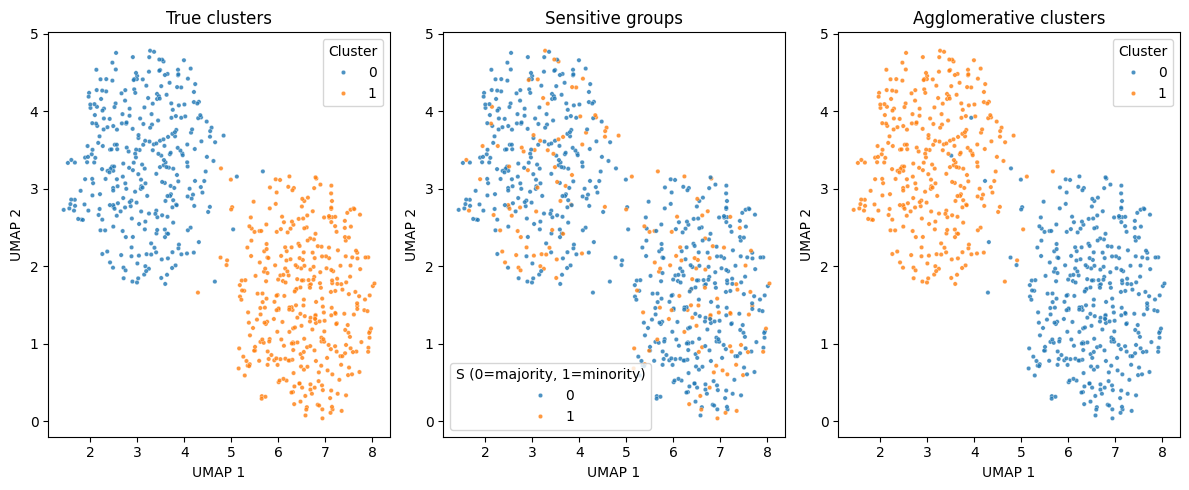

In [484]:
reducer = umap.UMAP(random_state=42)

scaled_df = StandardScaler().fit_transform(X_train_true)
embedding = reducer.fit_transform(scaled_df)
embedding.shape

plt.figure(figsize=(12, 5))

# 1) True latent substructure (clusters C)
plt.subplot(1, 3, 1)
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=clusters_train,
    palette="tab10",
    s=10,
    alpha=0.8,
    legend="full"
)
plt.title("True clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster", loc="best")

# 2) Sensitive attribute (majority / minority)
plt.subplot(1, 3, 2)
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=sensitive_train,
    palette=["tab:blue", "tab:orange"],  # 0=majority, 1=minority
    s=10,
    alpha=0.8,
    legend="full"
)
plt.title("Sensitive groups")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="S (0=majority, 1=minority)", loc="best")

plt.subplot(1, 3, 3)
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=labels_true,
    palette=["tab:blue", "tab:orange"],  # 0=majority, 1=minority
    s=10,
    alpha=0.8,
    legend="full"
)
plt.title("Agglomerative clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster", loc="best")

plt.tight_layout()
plt.show()


In [462]:
row_missing_frac_train = missing_mask_train.mean(axis=1)
high_missing = row_missing_frac_train > 0.5

reducer = umap.UMAP(random_state=42)

train_imp, test_imp = impute(method="MissForest")
scaled_df_missforest = StandardScaler().fit_transform(train_imp)
embedding_missforest = reducer.fit_transform(scaled_df_missforest)

train_imp, test_imp = impute(method="Mean")
scaled_df_mean = StandardScaler().fit_transform(train_imp)
embedding_mean = reducer.fit_transform(scaled_df_mean)

train_imp, test_imp = impute(method="Median")
scaled_df_median = StandardScaler().fit_transform(train_imp)
embedding_median = reducer.fit_transform(scaled_df_median)

train_imp = pd.read_csv("/Users/minhu/CS6530/Project/Final/cVAE_imputed_train.csv",header=None).to_numpy()
scaled_df_cvae = StandardScaler().fit_transform(train_imp)
embedding_cvae = reducer.fit_transform(scaled_df_cvae)

/Users/minhu/anaconda3/envs/squidpy/lib/python3.10/site-packages/missforest/missforest.py:333: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
100%|██████████| 5/5 [04:29<00:00, 53.95s/it]
/Users/minhu/anaconda3/envs/squidpy/lib/python3.10/site-packages/missforest/missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
/Users/minhu/anaconda3/envs/squidpy/lib/python3.10/site-packages/missforest/missforest.py:494: UserWarning: In version 4.2.3, estimator fitting process is moved to `fit` method. `MissForest` will now imputes unseen missing values with fitted estimators with `transform` method. To retain the old behaviour, use `fit_transform` to fit the whole unseen data 

/Users/minhu/anaconda3/envs/squidpy/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


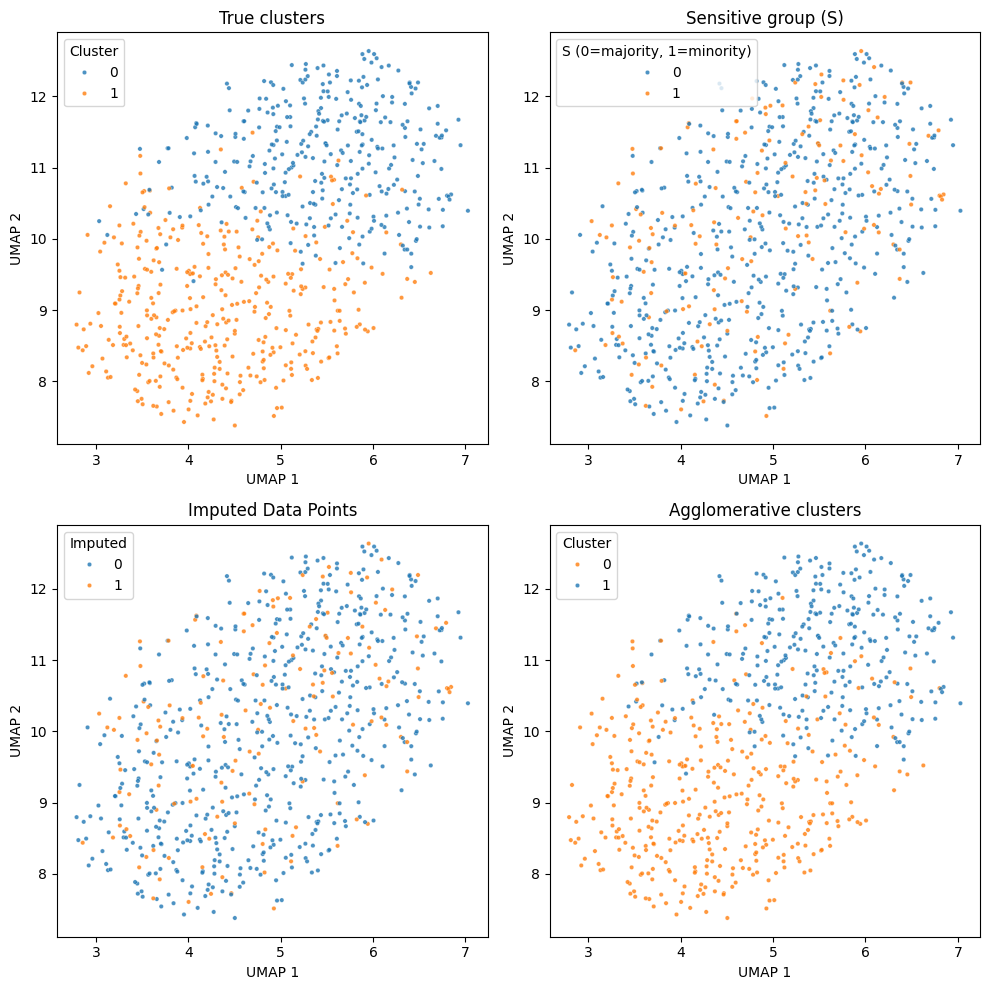

In [469]:
row_missing_frac_train = missing_mask_train.mean(axis=1)
high_missing = row_missing_frac_train > 0.5

reducer = umap.UMAP(random_state=42)

scaled_df = StandardScaler().fit_transform(train_imp)
embedding = reducer.fit_transform(scaled_df)
embedding.shape

plt.figure(figsize=(10, 10))

# 1) True latent substructure (clusters C)
plt.subplot(2, 2, 1)
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=clusters_train,
    palette="tab10",
    s=10,
    alpha=0.8,
    legend="full"
)
plt.title("True clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster", loc="best")

# 2) Sensitive attribute (majority / minority)
plt.subplot(2, 2, 2)
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=sensitive_train,
    palette=["tab:blue", "tab:orange"],  # 0=majority, 1=minority
    s=10,
    alpha=0.8,
    legend="full"
)
plt.title("Sensitive group (S)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="S (0=majority, 1=minority)", loc="best")

# 3) Sensitive attribute (majority / minority)
plt.subplot(2, 2, 3)
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=high_missing.astype(int),
    palette=["tab:blue", "tab:orange"],  # 0=majority, 1=minority
    s=10,
    alpha=0.8,
    legend="full"
)
plt.title("Imputed Data Points")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Imputed", loc="best")

plt.subplot(2, 2, 4)
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=labels_imp,
    palette=["tab:orange", "tab:blue"],  # 0=majority, 1=minority
    s=10,
    alpha=0.8,
    legend="full"
)
plt.title("Agglomerative clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster", loc="best")

plt.tight_layout()
plt.show()

# Prediction

## Classification

### Original Data

#### Training Data

In [427]:
clf = LogisticRegression(random_state=0).fit(X_train_true, y_class_train)
orginal_data_train_overall = clf.score(X_train_true, y_class_train)
print(orginal_data_train_overall)

1.0


In [428]:
orginal_data_train_major = clf.score(X_train_true[train_maj], y_class_train[train_maj])
print(orginal_data_train_major)

1.0


In [429]:
orginal_data_train_minor = clf.score(X_train_true[train_min], y_class_train[train_min])
print(orginal_data_train_minor)

1.0


#### Test Data

In [342]:
orginal_data_test_overall = clf.score(X_test_true, y_class_test)
print(orginal_data_test_overall)

0.9466666666666667


In [343]:
orginal_data_test_major = clf.score(X_test_true[test_maj], y_class_test[test_maj])
print(orginal_data_test_major)

0.957983193277311


In [344]:
orginal_data_test_minor = clf.score(X_test_true[test_min], y_class_test[test_min])
print(orginal_data_test_minor)

0.9032258064516129


### Imputed Data

#### Training Data

In [470]:
clf = LogisticRegression(random_state=0).fit(train_imp, y_class_train)
imputed_data_train_overall = clf.score(train_imp, y_class_train)
print(imputed_data_train_overall)

imputed_data_train_major = clf.score(train_imp[train_maj], y_class_train[train_maj])
print(imputed_data_train_major)

imputed_data_train_minor = clf.score(train_imp[train_min], y_class_train[train_min])
print(imputed_data_train_minor)

0.9328571428571428
0.9650092081031307
0.821656050955414


#### Test Data

In [471]:
imputed_data_test_overall = clf.score(test_imp, y_class_test)
print(imputed_data_test_overall)

imputed_data_test_major = clf.score(test_imp[test_maj], y_class_test[test_maj])
print(imputed_data_test_major)

imputed_data_test_minor = clf.score(test_imp[test_min], y_class_test[test_min])
print(imputed_data_test_minor)

0.87
0.8991596638655462
0.7580645161290323


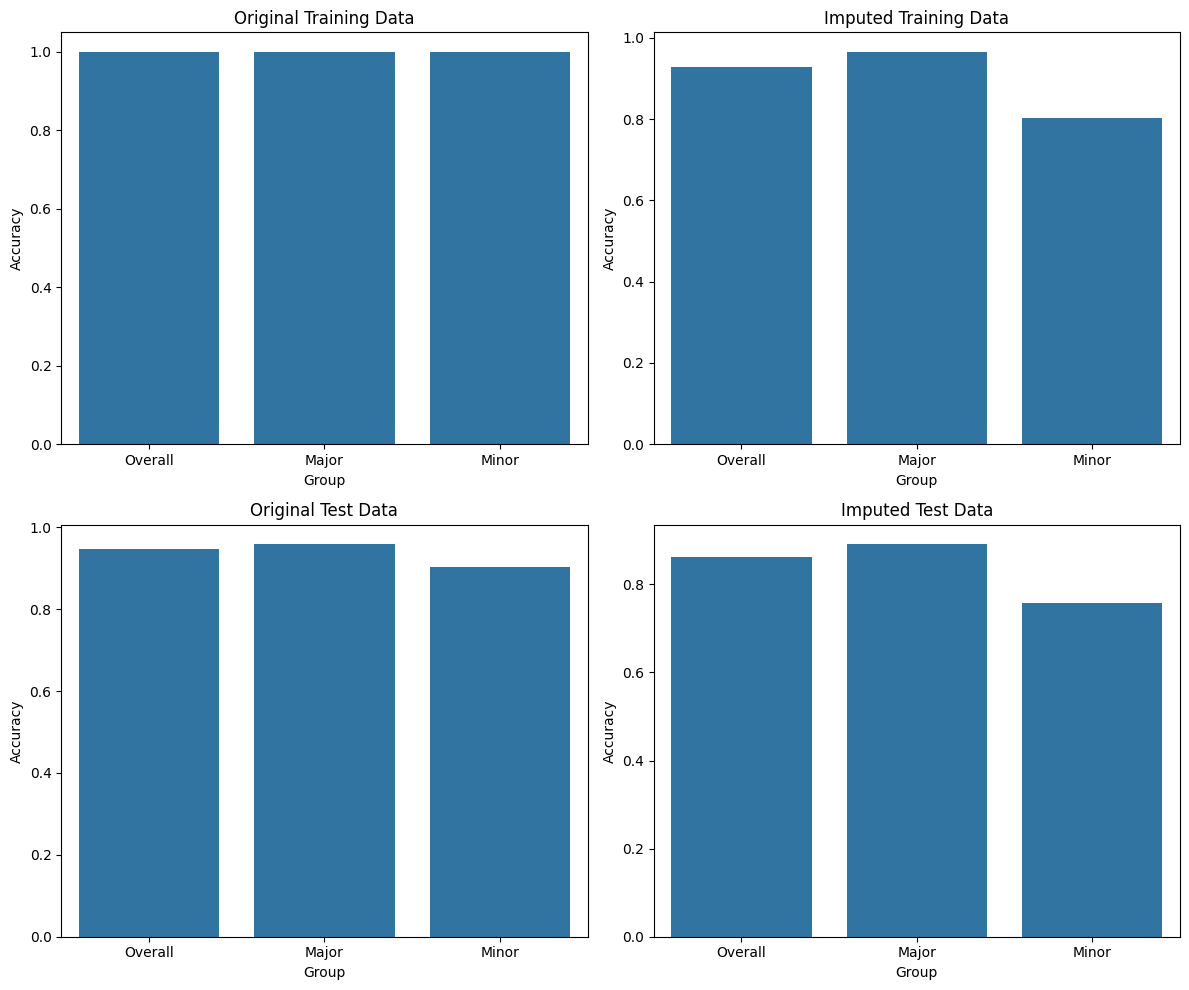

In [311]:
original_train_df = pd.DataFrame({"Overall": [orginal_data_train_overall],
                   "Major": [orginal_data_train_major],
                   "Minor": [orginal_data_train_minor]})

original_test_df = pd.DataFrame({"Overall": [orginal_data_test_overall], 
                   "Major": [orginal_data_test_major], 
                   "Minor": [orginal_data_test_minor]})

imputed_train_df = pd.DataFrame({
                   "Overall": [imputed_data_train_overall], 
                   "Major": [imputed_data_train_major], 
                   "Minor": [imputed_data_train_minor]})

imputed_test_df = pd.DataFrame({
                   "Overall": [imputed_data_test_overall], 
                   "Major": [imputed_data_test_major], 
                   "Minor": [imputed_data_test_minor]
                   })

original_train_df_long = original_train_df.melt(var_name="Group", value_name="Accuracy")
original_test_df_long = original_test_df.melt(var_name="Group", value_name="Accuracy")
imputed_train_df_long = imputed_train_df.melt(var_name="Group", value_name="Accuracy")
imputed_test_df_long = imputed_test_df.melt(var_name="Group", value_name="Accuracy")

plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.barplot(data=original_train_df_long, x="Group", y="Accuracy")
plt.title("Original Training Data")

plt.subplot(2,2,2)
sns.barplot(data=imputed_train_df_long, x="Group", y="Accuracy")
plt.title("Imputed Training Data")

plt.subplot(2,2,3)
sns.barplot(data=original_test_df_long, x="Group", y="Accuracy")
plt.title("Original Test Data")

plt.subplot(2,2,4)
sns.barplot(data=imputed_test_df_long, x="Group", y="Accuracy")
plt.title("Imputed Test Data")

plt.tight_layout()
plt.show()

## Regression

### Original Data

#### Training Data

In [312]:
clf = LinearRegression().fit(X_train_true, y_reg_train)
y_pred_train = clf.predict(X_train_true)
orginal_data_train_overall = mean_squared_error(y_pred_train, y_reg_train)
print(orginal_data_train_overall)

0.9491200606632967


In [313]:
y_pred_train = clf.predict(X_train_true[train_maj])
orginal_data_train_major = mean_squared_error(y_pred_train, y_reg_train[train_maj])
print(orginal_data_train_major)

0.9432300966379957


In [314]:
y_pred_train = clf.predict(X_train_true[train_min])
orginal_data_train_minor = mean_squared_error(y_pred_train, y_reg_train[train_min])
print(orginal_data_train_minor)

0.9694910827380635


In [447]:
clf = LinearRegression().fit(X_train_true, y_reg_train)
y_pred_train = clf.predict(X_train_true)
orginal_data_train_overall = mean_squared_error(y_pred_train, y_reg_train)
print(orginal_data_train_overall)

y_pred_train = clf.predict(X_train_true[train_maj])
orginal_data_train_major = mean_squared_error(y_pred_train, y_reg_train[train_maj])
print(orginal_data_train_major)

y_pred_train = clf.predict(X_train_true[train_min])
orginal_data_train_minor = mean_squared_error(y_pred_train, y_reg_train[train_min])
print(orginal_data_train_minor)

0.9491200606632967
0.9432300966379957
0.9694910827380635


#### Test Data

In [315]:
y_pred_test = clf.predict(X_test_true)
orginal_data_test_overall = mean_squared_error(y_pred_test, y_reg_test)
print(orginal_data_test_overall)

1.219016897423245


In [316]:
y_pred_test = clf.predict(X_test_true[test_maj])
orginal_data_test_major = mean_squared_error(y_pred_test, y_reg_test[test_maj])
print(orginal_data_test_major)

1.2153377927054636


In [317]:
y_pred_test = clf.predict(X_test_true[test_min])
orginal_data_test_minor = mean_squared_error(y_pred_test, y_reg_test[test_min])
print(orginal_data_test_minor)

1.2331399123076303


### Imputed Data

#### Training Data

In [472]:
clf = LinearRegression().fit(train_imp, y_reg_train)
y_pred_train = clf.predict(train_imp)
imputed_data_train_overall = mean_squared_error(y_pred_train, y_reg_train)
print(imputed_data_train_overall)

y_pred_train = clf.predict(train_imp[train_maj])
imputed_data_train_major = mean_squared_error(y_pred_train, y_reg_train[train_maj])
print(imputed_data_train_major)

y_pred_train = clf.predict(train_imp[train_min])
imputed_data_train_minor = mean_squared_error(y_pred_train, y_reg_train[train_min])
print(imputed_data_train_minor)

43.99554032125559
17.328937366540252
136.2246193302392


#### Test Data

In [473]:
y_pred_test = clf.predict(test_imp)
imputed_data_test_overall = mean_squared_error(y_pred_test, y_reg_test)
print(imputed_data_test_overall)

y_pred_test = clf.predict(test_imp[test_maj])
imputed_data_test_major = mean_squared_error(y_pred_test, y_reg_test[test_maj])
print(imputed_data_test_major)

y_pred_test = clf.predict(test_imp[test_min])
imputed_data_test_minor = mean_squared_error(y_pred_test, y_reg_test[test_min])
print(imputed_data_test_minor)

42.36603535589337
16.675419566781855
140.98485080441827


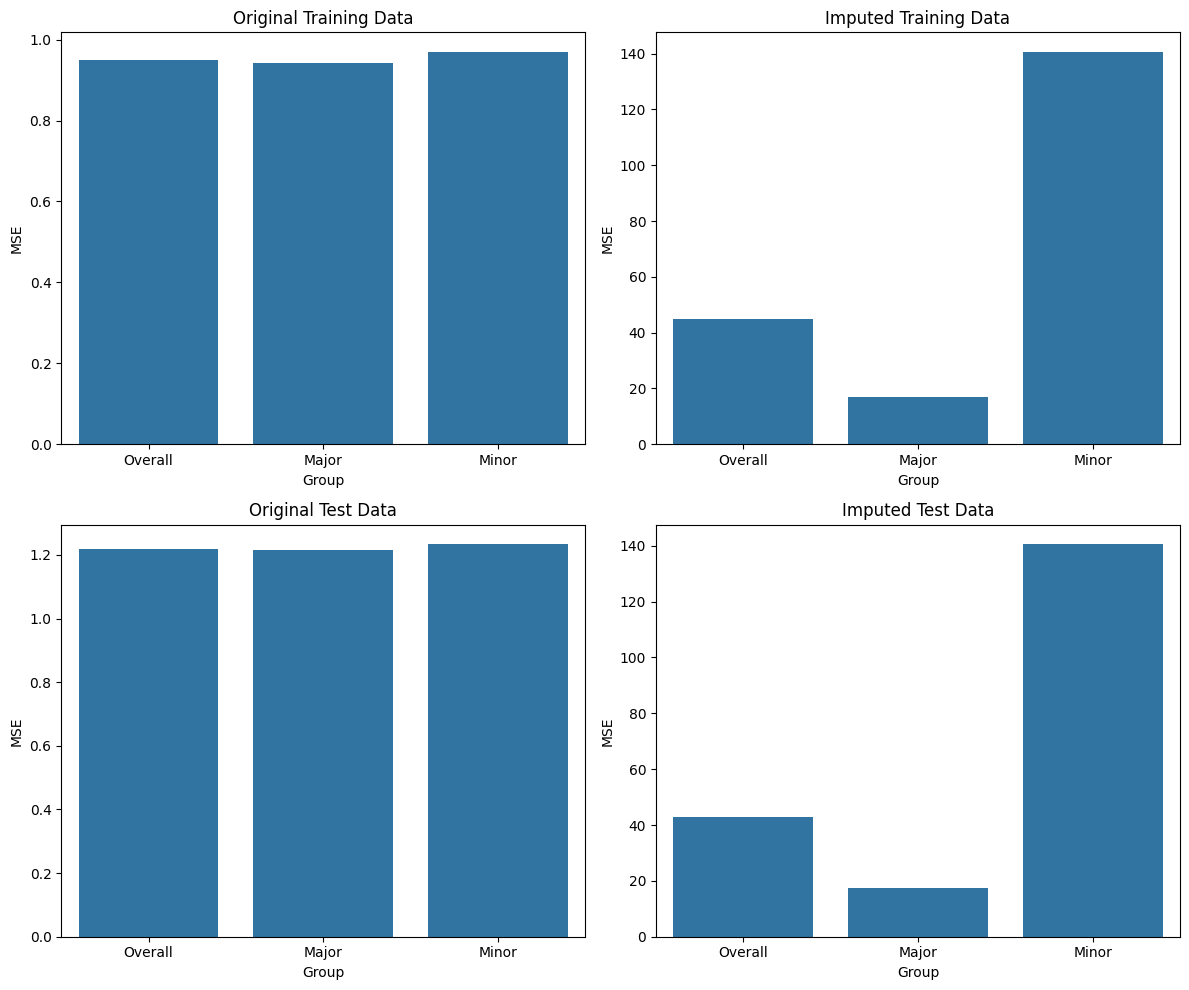

In [324]:
original_train_df = pd.DataFrame({"Overall": [orginal_data_train_overall],
                   "Major": [orginal_data_train_major],
                   "Minor": [orginal_data_train_minor]})

original_test_df = pd.DataFrame({"Overall": [orginal_data_test_overall], 
                   "Major": [orginal_data_test_major], 
                   "Minor": [orginal_data_test_minor]})

imputed_train_df = pd.DataFrame({
                   "Overall": [imputed_data_train_overall], 
                   "Major": [imputed_data_train_major], 
                   "Minor": [imputed_data_train_minor]})

imputed_test_df = pd.DataFrame({
                   "Overall": [imputed_data_test_overall], 
                   "Major": [imputed_data_test_major], 
                   "Minor": [imputed_data_test_minor]
                   })

original_train_df_long = original_train_df.melt(var_name="Group", value_name="MSE")
original_test_df_long = original_test_df.melt(var_name="Group", value_name="MSE")
imputed_train_df_long = imputed_train_df.melt(var_name="Group", value_name="MSE")
imputed_test_df_long = imputed_test_df.melt(var_name="Group", value_name="MSE")

plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.barplot(data=original_train_df_long, x="Group", y="MSE")
plt.title("Original Training Data")

plt.subplot(2,2,2)
sns.barplot(data=imputed_train_df_long, x="Group", y="MSE")
plt.title("Imputed Training Data")

plt.subplot(2,2,3)
sns.barplot(data=original_test_df_long, x="Group", y="MSE")
plt.title("Original Test Data")

plt.subplot(2,2,4)
sns.barplot(data=imputed_test_df_long, x="Group", y="MSE")
plt.title("Imputed Test Data")

plt.tight_layout()
plt.show()

# Save as JSON

In [486]:
# ---------- helpers ----------

def to_point_list(umap_array, groups, pred_clusters):
    """
    Convert an (n, 2) UMAP array + group labels into
    a list of {x, y, group} objects for JS.
    """
    umap_array = np.asarray(umap_array)
    points = []
    for i in range(umap_array.shape[0]):
        points.append({
            "x": float(umap_array[i, 0]),
            "y": float(umap_array[i, 1]),
            "true": str(groups[i]),
            "cluster": str(pred_clusters[i]),
        })
    return points

def make_json_safe(obj):
    """
    Recursively convert numpy types → plain Python
    so json.dump doesn't choke.
    """
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

# ---------- build the DATA object ----------

def build_data_object(
    umap_gt,
    true_labels,
    pred_clusters_gt,          # clustering on ground-truth data
    umap_by_method,            # dict[method_name] -> (n, 2)
    pred_clusters_by_method,   # dict[method_name] -> (n,)
    metrics_by_method,         # dict[method_name] -> dict of scalars
    output_path="imputation_viz_data.json",
):
    data = {
        "groundTruth": {
            "umap": to_point_list(
                umap_gt,
                groups=true_labels,
                pred_clusters=pred_clusters_gt,
            ),
        },
        "imputations": {},
    }

    for method_name, umap_arr in umap_by_method.items():
        data["imputations"][method_name] = {
            "umap": to_point_list(
                umap_arr,
                groups=true_labels,
                pred_clusters=pred_clusters_by_method[method_name],
            ),
            "metrics": make_json_safe(metrics_by_method.get(method_name, {})),
        }

    data_safe = make_json_safe(data)
    output_path = Path(output_path)

    with output_path.open("w", encoding="utf-8") as f:
        json.dump(data_safe, f, indent=2)

    print(f"Wrote JSON for JS to: {output_path.resolve()}")

In [487]:
MSIE_train_by_method={
        "mean": 1.1012576301973416,
        "median": 1.1019268472721544,
        "MissForest": 1.8617618731609706,
        "cVAE": 1.0611979940645706
    }
MSIE_test_by_method={
        "mean": 1.1025199287650969,
        "median": 1.101960133709083,
        "MissForest": 1.9918498368476942,
        "cVAE": 1.064652993721682
    }
IFR_train_by_method={
    "mean": 0.019869343689841834,
    "median": 0.02009531510582696,
    "MissForest": 0.6530740025467567,
    "cVAE": 0.07819317074420495
}
IFR_test_by_method={
    "mean": 0.056527002982624364,
    "median": 0.053842398818955806,
    "MissForest": 0.7338255871788448,
    "cVAE": 0.0242605720299347
}
FIS_train_by_method={
    "mean": 2.21349325682069,
    "median": 2.214956542270681,
    "MissForest": 4.66884231599016,
    "cVAE": 2.165598439220011
}
FIS_test_by_method={
    "mean": 2.2843551345943234,
    "median": 2.2794686700362132,
    "MissForest": 5.01335942377499,
    "cVAE": 2.1437861618647043
}
ARI_major_by_method={
    "mean": 0.9490054239805346,
    "median": 0.9562088404568876,
    "MissForest": 0.9418292361356084,
    "cVAE": 0.9634394138842292
}
ARI_minor_by_method={
    "mean": 0.248726318840691,
    "median": 0.3622753585695519,
    "MissForest": 0.3938908692005482,
    "cVAE": 0.5914270914892585
}
NMI_major_by_method={
    "mean": 0.9056149220084453,
    "median": 0.9122083334656054,
    "MissForest": 0.8897453188764219,
    "cVAE": 0.9246753497494584
}
NMI_minor_by_method={
    "mean": 0.29610902297491215,
    "median": 0.41492355655498314,
    "MissForest": 0.38134862123725977,
    "cVAE": 0.5797349837897965
}
accuracy_train_overall_by_method={
    "mean": 0.9285714285714286,
    "median": 0.9257142857142857,
    "MissForest": 0.9257142857142857,
    "cVAE": 0.9328571428571428
}
accuracy_train_major_by_method={
    "mean": 0.9650092081031307,
    "median": 0.9631675874769797,
    "MissForest": 0.9631675874769797,
    "cVAE": 0.9650092081031307
}
accuracy_train_minor_by_method={
    "mean": 0.802547770700637,
    "median": 0.7961783439490446,
    "MissForest": 0.7961783439490446,
    "cVAE": 0.821656050955414
}
accuracy_test_overall_by_method={
    "mean": 0.8633333333333333,
    "median": 0.86,
    "MissForest": 0.8566666666666667,
    "cVAE": 0.87
}
accuracy_test_major_by_method={
    "mean": 0.8907563025210085,
    "median": 0.8865546218487395,
    "MissForest": 0.8739495798319328,
    "cVAE": 0.8991596638655462
}
accuracy_test_minor_by_method={
    "mean": 0.7580645161290323,
    "median": 0.7580645161290323,
    "MissForest": 0.7903225806451613,
    "cVAE": 0.7580645161290323
}
MSE_train_overall_by_method={
    "mean": 44.781244748171915,
    "median": 44.49383225236423,
    "MissForest": 44.525493451111295,
    "cVAE": 43.99554032125559
}
MSE_train_major_by_method={
    "mean": 17.072342033427446,
    "median": 16.931869341805807,
    "MissForest": 16.95324067572271,
    "cVAE": 17.328937366540252
}
MSE_train_minor_by_method={
    "mean": 140.61522037942186,
    "median": 139.81960206404082,
    "MissForest": 139.88685177618137,
    "cVAE": 136.2246193302392
}
MSE_test_overall_by_method={
    "mean": 42.984284894666665,
    "median": 42.83438039899191,
    "MissForest": 45.9913690842999,
    "cVAE": 42.36603535589337
}
MSE_test_major_by_method={
    "mean": 17.586273718207273,
    "median": 17.378630841201506,
    "MissForest": 20.01186404069144,
    "cVAE": 16.675419566781855
}
MSE_test_minor_by_method={
    "mean": 140.47987618494625,
    "median": 140.55161257244544,
    "MissForest": 145.71914650976464,
    "cVAE": 140.98485080441827
}

In [488]:
methods = ["mean", "median", "MissForest", "cVAE"]

metrics_by_method = {}
for m in methods:
    metrics_by_method[m] = {
        "MSIE_train": MSIE_train_by_method[m],
        "MSIE_test": MSIE_test_by_method[m],
        "IFR_train": IFR_train_by_method[m],
        "IFR_test": IFR_test_by_method[m],
        "FIS_train": FIS_train_by_method[m],
        "FIS_test": FIS_test_by_method[m],
        "accuracy_train_overall": accuracy_train_overall_by_method[m],
        "accuracy_train_major": accuracy_train_major_by_method[m],
        "accuracy_train_minor": accuracy_train_minor_by_method[m],
        "accuracy_test_overall": accuracy_test_overall_by_method[m],
        "accuracy_test_major": accuracy_test_major_by_method[m],
        "accuracy_test_minor": accuracy_test_minor_by_method[m],
        "MSE_train_overall": MSE_train_overall_by_method[m],
        "MSE_train_major": MSE_train_major_by_method[m],
        "MSE_train_minor": MSE_train_minor_by_method[m],
        "MSE_test_overall": MSE_test_overall_by_method[m],
        "MSE_test_major": MSE_test_major_by_method[m],
        "MSE_test_minor": MSE_test_minor_by_method[m],
        "ARI_major": ARI_major_by_method[m],
        "ARI_minor": ARI_minor_by_method[m],
        "NMI_major": NMI_major_by_method[m],
        "NMI_minor": NMI_minor_by_method[m],
    }


In [490]:
umap_by_method = {
    "mean": embedding_mean,
    "median": embedding_median,
    "MissForest": embedding_missforest,
    "cVAE": embedding_cvae,
}

pred_clusters_by_method = {
    "mean": labels_imp_mean,
    "median": labels_imp_median,
    "MissForest": labels_imp_missforest,
    "cVAE": labels_imp_cvae,
}

build_data_object(
    umap_gt=embedding,
    true_labels=clusters_labels,
    pred_clusters_gt=clusters_labels,         # or clusters_mean if you prefer
    umap_by_method=umap_by_method,
    pred_clusters_by_method=pred_clusters_by_method,
    metrics_by_method=metrics_by_method,
    output_path="imputation_viz_data.json",
)

Wrote JSON for JS to: /Users/minhu/CS6530/Project/Final/Code/imputation_viz_data.json
